# 🏥 Phase 1 — Problem Statement 1: Shortage of Doctors in Rural India

---

## Project Context
This notebook is part of a **Phase 1 Exploratory Data Analysis** for understanding real-world problems in the Indian healthcare system through a data-driven approach. Rather than jumping to solutions, the focus is on:
- **Framing the problem clearly**
- **Understanding who is affected and why**
- **Deriving insights from credible government datasets (RHS — Rural Health Statistics)**

---

## Problem Statement
> **India's rural healthcare infrastructure suffers from a severe and persistent shortage of doctors and specialists. Despite expansion of Sub-Centres, PHCs, and CHCs over the years, the number of sanctioned positions vastly exceeds the actual postings — leaving crores of rural citizens without adequate medical care.**

---

## Datasets Used
| Dataset | Description | Year |
|---|---|---|
| `rhs_2005.csv` | State-wise rural health workforce — facilities & staff | 2005 |
| `rhs_2019.csv` | State-wise rural health workforce — facilities & staff | 2019 |
| `rhs_2020.csv` | State-wise rural health workforce — facilities & staff | 2020 |
| `RHS_2020_21_and_2021_22` | State-wise rural health workforce — facilities & staff | 2020-22 |
| `rhs_2020_vacancies_shortfalls.csv` | Vacancies & shortfalls across staff categories | 2020 |
| `rhs_population_density.csv` | Rural/Urban population split by state | 2011 Census |
| `rhs_villages_districts_area.csv` | Villages, districts, and area by state | 2011 Census |

---

## Notebook Structure
1. Setup & Data Loading
2. Data Understanding
3. Data Cleaning
4. Exploratory Analysis & Visualizations
   - Doctor counts across states (2005 vs 2019 vs 2020)
   - Specialist shortage analysis
   - Vacancy & shortfall heatmap
   - Rural population vs doctor availability
   - Infrastructure growth vs workforce gap
   - State-wise vulnerability ranking
5. Key Insights & Problem Framing


---
## Section 1 — Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Visual Style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': '#F9F9F9',
    'axes.facecolor': '#F9F9F9',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})
PALETTE = ['#1A535C', '#4ECDC4', '#FF6B6B', '#FFE66D', '#A8DADC', '#457B9D', '#E63946']
print('✅ Libraries loaded and styles set.')

✅ Libraries loaded and styles set.


In [2]:
# ── Load all six datasets ─────────────────────────────────────────────────────
# Place all CSVs in a folder called 'datasets/' relative to this notebook
BASE = 'datasets/'   # Change path if your CSVs are elsewhere

rhs05  = pd.read_csv(BASE + 'rhs_2005.csv')
rhs19  = pd.read_csv(BASE + 'rhs_2019.csv')
rhs20  = pd.read_csv(BASE + 'rhs_2020.csv')
vac    = pd.read_csv(BASE + 'rhs_2020_vacancies_shortfalls.csv')
popden = pd.read_csv(BASE + 'rhs_population_density.csv')
geo    = pd.read_csv(BASE + 'rhs_villages_districs_area.csv')

print('✅ All datasets loaded.')
for name, df in [('RHS 2005', rhs05), ('RHS 2019', rhs19), ('RHS 2020', rhs20),
                 ('Vacancies 2020', vac), ('Population Density', popden), ('Geo/Villages', geo)]:
    print(f'   {name:25s} → {df.shape[0]} rows × {df.shape[1]} cols')


✅ All datasets loaded.
   RHS 2005                  → 38 rows × 11 cols
   RHS 2019                  → 38 rows × 11 cols
   RHS 2020                  → 38 rows × 11 cols
   Vacancies 2020            → 38 rows × 15 cols
   Population Density        → 37 rows × 8 cols
   Geo/Villages              → 37 rows × 8 cols


---
## Section 2 — Data Understanding
### 2.1 — RHS 2005: Rural Health Workforce (Baseline Year)

In [3]:
print('='*65)
print('DATASET: Rural Health Statistics — 2005 (Baseline)')
print('='*65)
print(f'Shape: {rhs05.shape[0]} states/UTs × {rhs05.shape[1]} columns')
print()
print('Columns:')
for c in rhs05.columns:
    print(f'  • {c}')
print()
print('Sample rows:')
display(rhs05.head())
print()
print('Descriptive Statistics:')
display(rhs05.describe())
print()
print('Missing Values:')
print(rhs05.isnull().sum())

DATASET: Rural Health Statistics — 2005 (Baseline)
Shape: 38 states/UTs × 11 columns

Columns:
  • State/UT
  • SubCenters
  • PHCs
  • CHCs
  • ANM/Health_Worker_Female
  • Doctors
  • Specialists
  • Radiographers
  • Pharmacists
  • LabTechinicians
  • NursingStaff

Sample rows:


,State/UT,SubCenters,PHCs,CHCs,ANM/Health_Worker_Female,Doctors,Specialists,Radiographers,Pharmacists,LabTechinicians,NursingStaff
0,Andhra Pradesh,12522,1570,164,13740,2137,224,140,1637,1437,2053
1,Arunachal Pradesh,379,85,31,454,78,0,22,31,18,105
2,Assam,5109,610,100,5719,NaN,NaN,NaN,NaN,NaN,NaN
3,Bihar,10337,1648,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Chhattisgarh,3818,517,116,3667,628,18,95,467,348,540



Descriptive Statistics:


,State/UT,SubCenters,PHCs,CHCs,ANM/Health_Worker_Female,Doctors,Specialists,Radiographers,Pharmacists,LabTechinicians,NursingStaff
count,38,38,38,38,36,34,32,32,34,34,34
unique,38,37,37,32,35,32,22,25,32,31,32
top,Andhra Pradesh,-,-,4,-,53,0,4,-,32,-
freq,1,2,2,3,2,2,7,3,2,2,2



Missing Values:
State/UT                    0
SubCenters                  0
PHCs                        0
CHCs                        0
ANM/Health_Worker_Female    2
Doctors                     4
Specialists                 6
Radiographers               6
Pharmacists                 4
LabTechinicians             4
NursingStaff                4
dtype: int64


### 2.2 — RHS 2019 & 2020: Current Workforce Snapshots

In [4]:
print('='*65)
print('DATASET: Rural Health Statistics — 2019')
print('='*65)
display(rhs19.head())
print('Missing Values:')
print(rhs19.isnull().sum())

print()
print('='*65)
print('DATASET: Rural Health Statistics — 2020')
print('='*65)
display(rhs20.head())
print('Missing Values:')
print(rhs20.isnull().sum())

DATASET: Rural Health Statistics — 2019


,State/UT,SubCenters,PHCs,CHCs,ANM/Health_Worker_Female,Doctors,Specialists,Radiographers,Pharmacists,LabTechnicians,NursingStaff
0,Andhra Pradesh,7437,1145,140,11815,1715,237,40,1016,817,2861
1,Arunachal Pradesh,385,143,63,689,116,4,17,101,113,617
2,Assam,4643,946,177,11502,1925,136,90,1779,1409,3369
3,Bihar,9949,1899,150,24228,2085,82,1,287,611,1630
4,Chhattisgarh,5205,792,170,6808,321,61,161,1003,844,2618


Missing Values:
State/UT                    0
SubCenters                  0
PHCs                        0
CHCs                        0
ANM/Health_Worker_Female    0
Doctors                     0
Specialists                 0
Radiographers               0
Pharmacists                 0
LabTechnicians              0
NursingStaff                0
dtype: int64

DATASET: Rural Health Statistics — 2020


,State/UT,SubCenters,PHCs,CHCs,ANM/Health_Worker_Female,Doctors,Specialists,Radiographers,Pharmacists,LabTechnicians,NursingStaff
0,Andhra Pradesh,7437.0,1142.0,141.0,15742,1798,315,56,1039,913,3088
1,Arunachal Pradesh,356.0,119.0,60.0,471,194,14,13,108,120,679
2,Assam,4659.0,946.0,190.0,8614,1424,188,117,1384,1279,3575
3,Bihar,9112.0,1702.0,57.0,15656,1745,124,3,492,438,1346
4,Chhattisgarh,5205.0,792.0,170.0,5921,388,62,161,946,811,2718


Missing Values:
State/UT                    0
SubCenters                  1
PHCs                        1
CHCs                        1
ANM/Health_Worker_Female    1
Doctors                     1
Specialists                 1
Radiographers               1
Pharmacists                 1
LabTechnicians              1
NursingStaff                1
dtype: int64


### 2.3 — Vacancies & Shortfalls 2020

In [5]:
print('='*65)
print('DATASET: Vacancies & Shortfalls — 2020')
print('='*65)
print(f'Shape: {vac.shape}')
print('Columns:', vac.columns.tolist())
print()
print('NOTE: Some cells contain "*" meaning data not reported.')
print('      These will be treated as NaN during cleaning.')
print()
display(vac.head(10))

DATASET: Vacancies & Shortfalls — 2020
Shape: (38, 15)
Columns: ['State/UT', 'ANM_Vacent', 'ANM_Shortfall', 'Doctors_Vacent', 'Doctors_Shortfall', 'Specialists_Vacent', 'Specialists_Shortfall', 'Radiographers_Vacent', 'Radiographers_Shortfall', 'Pharmacists_Vacent', 'Pharmacists_Shortfall', 'LabTechnicians_Vacent', 'LabTechnicians_Shortfall', 'NursingStaff_Vacent', 'Nursing_Shortfall']

NOTE: Some cells contain "*" meaning data not reported.
      These will be treated as NaN during cleaning.



,State/UT,ANM_Vacent,ANM_Shortfall,Doctors_Vacent,Doctors_Shortfall,Specialists_Vacent,Specialists_Shortfall,Radiographers_Vacent,Radiographers_Shortfall,Pharmacists_Vacent,Pharmacists_Shortfall,LabTechnicians_Vacent,LabTechnicians_Shortfall,NursingStaff_Vacent,Nursing_Shortfall
0,Andhra Pradesh,1384,*,63,*,63,249,56,85,224,244,328,370,333,*
1,Arunachal Pradesh,NaN,4,NaN,*,NaN,226,NaN,47,NaN,71,NaN,59,NaN,*
2,Assam,*,*,*,*,*,572,*,73,*,*,*,*,*,*
3,Bihar,8465,*,2384,*,512,104,91,54,1075,1267,1068,1321,2248,755
4,Chhattisgarh,456,76,423,404,519,618,9,9,133,16,189,151,468,*
5,Goa,*,*,*,*,*,10,2,4,*,4,*,17,*,*
6,Gujarat,2457,1073,379,*,255,1379,222,222,308,287,314,347,670,944
7,Haryana,803,*,275,*,108,445,71,80,251,98,271,103,728,*
8,Himachal Pradesh,617,992,251,93,*,319,12,59,212,138,191,601,216,917
9,Jharkhand,396,*,108,69,160,505,66,49,163,234,181,98,1025,600


### 2.4 — Population Density & Geographic Coverage

In [6]:
print('='*65)
print('DATASET: Population Density (Census 2011)')
print('='*65)
display(popden.head())
print('Descriptive Statistics:')
display(popden.describe())

print()
print('='*65)
print('DATASET: Villages, Districts & Area')
print('='*65)
display(geo.head())
display(geo.describe())

DATASET: Population Density (Census 2011)


,State/UT,Rural_Population,Rural_Population_Density,Urban_Population,Urban_Population_Density,Total_Population,Total_Population_Density,Rural_Population_%
0,Andhra Pradesh**,34256000,216,18343000,4453,52599000,323,65.1
1,Arunachal Pradesh,1141000,NaN,381000,NaN,1522000,18,75.0
2,Assam,29492000,382,5301000,4208,34793000,444,84.8
3,Bihar,107187000,1167,14708000,6327,121895000,1295,87.9
4,Chhattisgarh,21557000,164,7680000,2271,29237000,216,73.7


Descriptive Statistics:


,Rural_Population,Urban_Population,Total_Population,Total_Population_Density,Rural_Population_%
count,3.700000e+01,3.700000e+01,3.700000e+01,37.00000,37.000000
mean,4.812619e+07,2.502957e+07,7.315576e+07,1175.27027,57.205405
std,1.466470e+08,7.561220e+07,2.215810e+08,2753.22450,23.237971
min,3.000000e+03,6.500000e+04,6.800000e+04,5.00000,0.300000
25%,5.500000e+05,9.140000e+05,1.553000e+06,146.00000,52.200000
50%,1.077700e+07,7.680000e+06,2.921300e+07,380.00000,63.700000
75%,3.638000e+07,2.062300e+07,6.649600e+07,661.00000,73.700000
max,8.903290e+08,4.630490e+08,1.353378e+09,13701.00000,89.800000



DATASET: Villages, Districts & Area


,State/UT,Tribal_Area,Rural_Area,Urban_Area,Total_Area,Rural_%,Number_of_Districts,Number_of_Villages
0,Andhra Pradesh*,14132.00,158856.00,4119.00,162975.0,97.47,13,17950
1,Arunachal Pradesh,NaN,NaN,NaN,83743.0,NaN,20,5545
2,Assam,18549.42,77178.12,1259.88,78438.0,98.39,27,27927
3,Bihar,NaN,91838.28,2324.72,94163.0,97.53,38,45413
4,Chhattisgarh,82315.23,131810.30,3381.70,135192.0,97.50,27,20618


,Tribal_Area,Rural_Area,Urban_Area,Total_Area,Rural_%,Number_of_Districts,Number_of_Villages
count,24.000000,3.600000e+01,36.000000,3.700000e+01,36.000000,37.000000,37.000000
mean,45795.062917,1.715620e+05,5679.154444,1.769775e+05,85.800000,38.108108,35917.243243
std,110313.212125,5.085511e+05,16881.306760,5.316886e+05,27.071998,113.758463,108621.772737
min,0.000000,0.000000e+00,0.000000,3.000000e+01,0.000000,1.000000,0.000000
25%,4024.500000,1.477517e+04,263.985000,1.657900e+04,93.052500,9.000000,864.000000
50%,19159.785000,5.727409e+04,1617.980000,5.914600e+04,97.115000,20.000000,11227.000000
75%,36662.030000,1.539805e+05,5341.442500,1.557070e+05,98.330000,30.000000,32712.000000
max,549541.000000,3.088115e+06,102225.000000,3.274083e+06,100.000000,705.000000,664469.000000


---
## Section 3 — Data Cleaning

In [7]:
# ── Standardise state names ───────────────────────────────────────────────────
def clean_state(s):
    return str(s).strip().replace('**','').replace('*','').strip()

for df in [rhs05, rhs19, rhs20, vac, popden, geo]:
    df['State/UT'] = df['State/UT'].apply(clean_state)

# ── Replace '*' (unreported) with NaN; coerce all numeric cols ───────────────
vac.replace('*', np.nan, inplace=True)
for df in [rhs05, rhs19, rhs20, vac]:
    for col in df.columns[1:]:
        df[col] = pd.to_numeric(df[col], errors='coerce')
for df in [popden, geo]:
    for col in df.columns[1:]:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# ── Drop summary/total rows (last row is often 'India' aggregate) ─────────────
EXCLUDE = ['India', 'Total', 'All India']
for df in [rhs05, rhs19, rhs20, vac, popden, geo]:
    mask = df['State/UT'].str.strip().isin(EXCLUDE)
    df.drop(df[mask].index, inplace=True)
    df.reset_index(drop=True, inplace=True)

# ── Rename columns for consistency ───────────────────────────────────────────
rhs05.rename(columns={'LabTechinicians': 'LabTechnicians'}, inplace=True)

print('✅ Cleaning complete.')
print(f'   Working with {rhs20.shape[0]} states/UTs.')


✅ Cleaning complete.
   Working with 38 states/UTs.


In [8]:
# ── Merge 2020 data with population for per-capita analysis ──────────────────
merged = rhs20.merge(popden[['State/UT', 'Rural_Population', 'Rural_Population_%', 'Total_Population']],
                     on='State/UT', how='left')
merged = merged.merge(geo[['State/UT', 'Number_of_Villages', 'Number_of_Districts']],
                      on='State/UT', how='left')

# Doctors per 1 lakh rural population
merged['Doctors_per_lakh_rural'] = (merged['Doctors'] / merged['Rural_Population'] * 100000).round(2)
merged['Specialists_per_lakh_rural'] = (merged['Specialists'] / merged['Rural_Population'] * 100000).round(2)

print('✅ Merged dataset ready.')
merged[['State/UT','Doctors','Rural_Population','Doctors_per_lakh_rural']].dropna().head(8)

✅ Merged dataset ready.


,State/UT,Doctors,Rural_Population,Doctors_per_lakh_rural
0,Andhra Pradesh,1798.0,34256000.0,5.25
1,Arunachal Pradesh,194.0,1141000.0,17.00
2,Assam,1424.0,29492000.0,4.83
3,Bihar,1745.0,107187000.0,1.63
4,Chhattisgarh,388.0,21557000.0,1.80
5,Goa,75.0,421000.0,17.81
6,Gujarat,1490.0,36380000.0,4.10
7,Haryana,491.0,17374000.0,2.83


---
## Section 4 — Exploratory Analysis & Visualizations

### 📊 Visualization 1 — Doctor Count by State: 2005 vs 2019 vs 2020

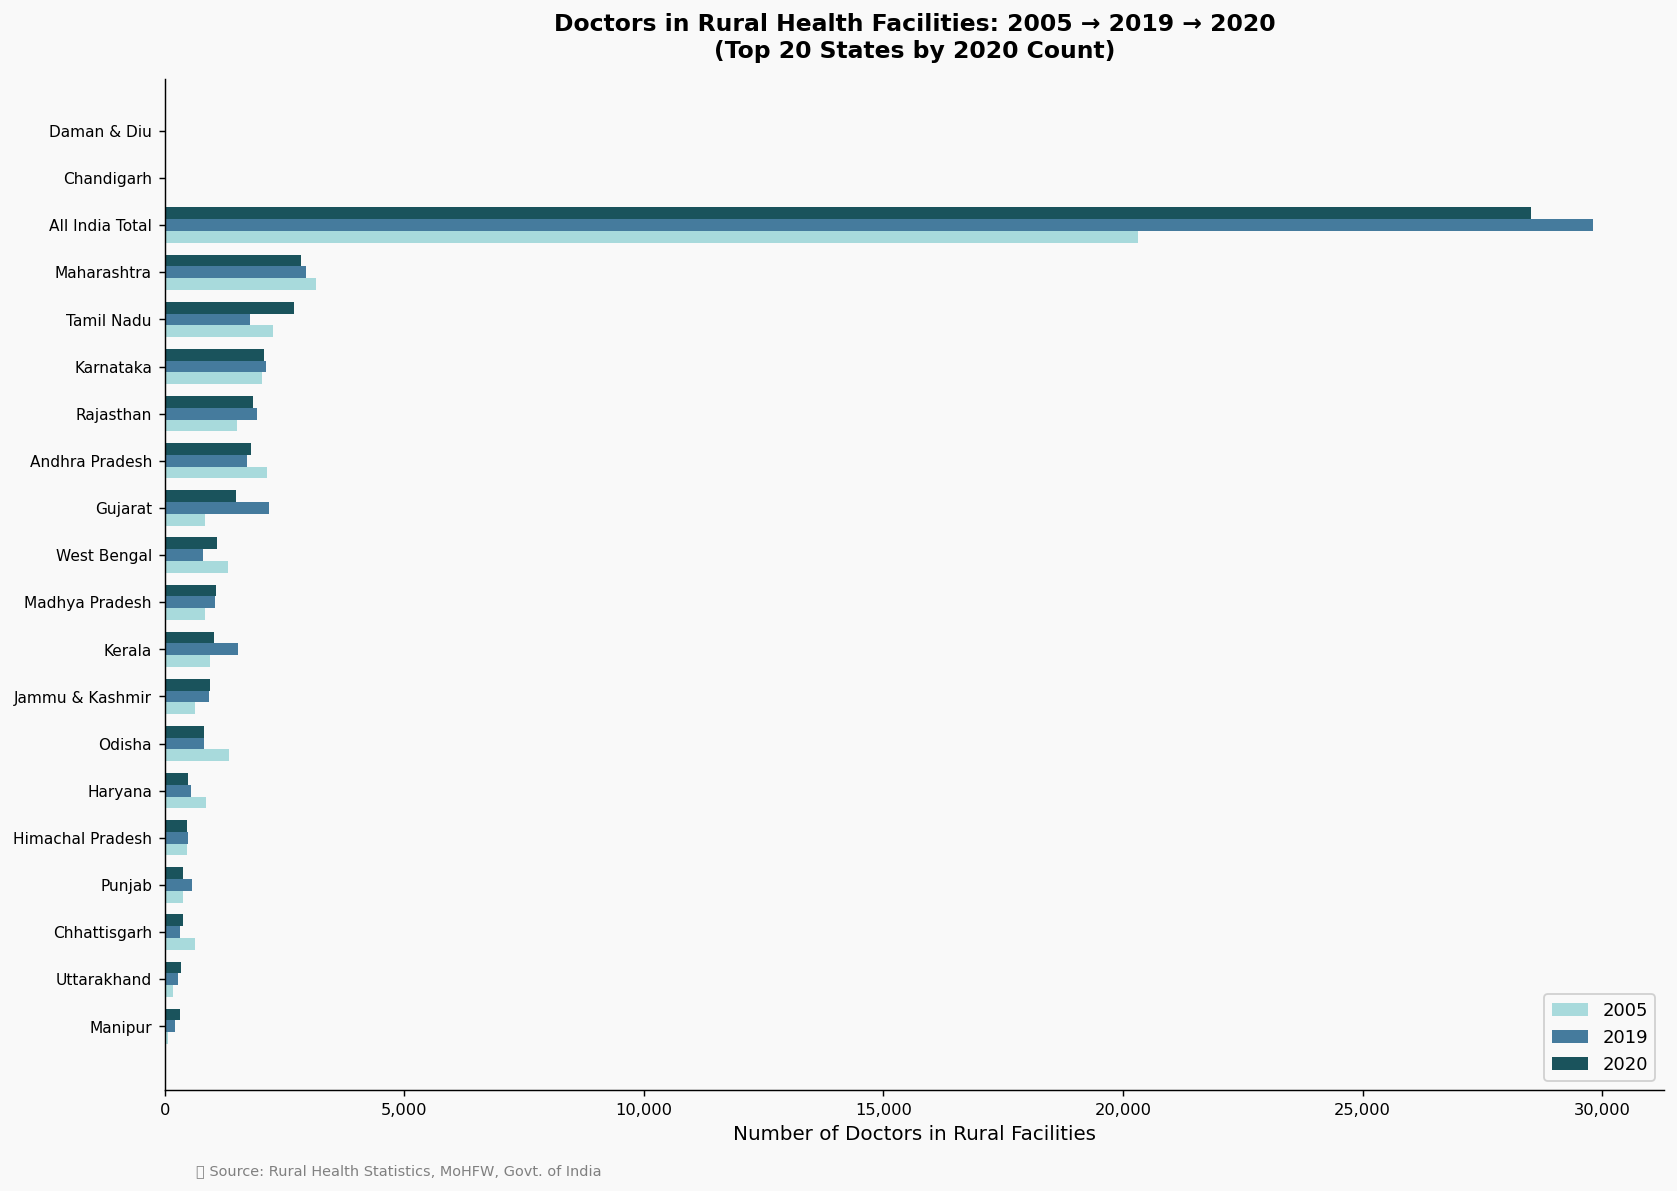


📋 Change in Doctor Count (2005 → 2020):


,State/UT,2005,2020,Change_05_20,%_Change
11,Manipur,67.0,311.0,244.0,364.2
21,Uttarakhand,182.0,346.0,164.0,90.1
4,Gujarat,848.0,1490.0,642.0,75.7
28,Jammu & Kashmir,643.0,940.0,297.0,46.2
31,All India Total,20308.0,28516.0,8208.0,40.4
9,Madhya Pradesh,839.0,1065.0,226.0,26.9
17,Rajasthan,1506.0,1845.0,339.0,22.5
19,Tamil Nadu,2257.0,2708.0,451.0,20.0
8,Kerala,949.0,1028.0,79.0,8.3
16,Punjab,373.0,391.0,18.0,4.8


In [9]:
# Merge three years on state
d05 = rhs05[['State/UT','Doctors']].rename(columns={'Doctors':'2005'}).dropna()
d19 = rhs19[['State/UT','Doctors']].rename(columns={'Doctors':'2019'})
d20 = rhs20[['State/UT','Doctors']].rename(columns={'Doctors':'2020'})
trend = d05.merge(d19, on='State/UT').merge(d20, on='State/UT')
trend = trend.sort_values('2020', ascending=True).tail(20)  # top 20 states

fig, ax = plt.subplots(figsize=(13, 9))
y = np.arange(len(trend))
h = 0.25
ax.barh(y - h, trend['2005'], h, color='#A8DADC', label='2005')
ax.barh(y,      trend['2019'], h, color='#457B9D', label='2019')
ax.barh(y + h,  trend['2020'], h, color='#1A535C', label='2020')
ax.set_yticks(y)
ax.set_yticklabels(trend['State/UT'], fontsize=8.5)
ax.set_xlabel('Number of Doctors in Rural Facilities')
ax.set_title('Doctors in Rural Health Facilities: 2005 → 2019 → 2020\n(Top 20 States by 2020 Count)', pad=12)
ax.legend(loc='lower right', framealpha=0.9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.axvline(0, color='grey', linewidth=0.5)
fig.text(0.12, -0.01, '📌 Source: Rural Health Statistics, MoHFW, Govt. of India', fontsize=8, color='grey')
plt.tight_layout()
plt.show()

# Change summary
trend['Change_05_20'] = trend['2020'] - trend['2005']
trend['%_Change']     = ((trend['2020'] - trend['2005']) / trend['2005'] * 100).round(1)
print('\n📋 Change in Doctor Count (2005 → 2020):')
display(trend[['State/UT','2005','2020','Change_05_20','%_Change']].sort_values('%_Change', ascending=False))

### 📊 Visualization 2 — Doctors per Lakh Rural Population (State-wise)

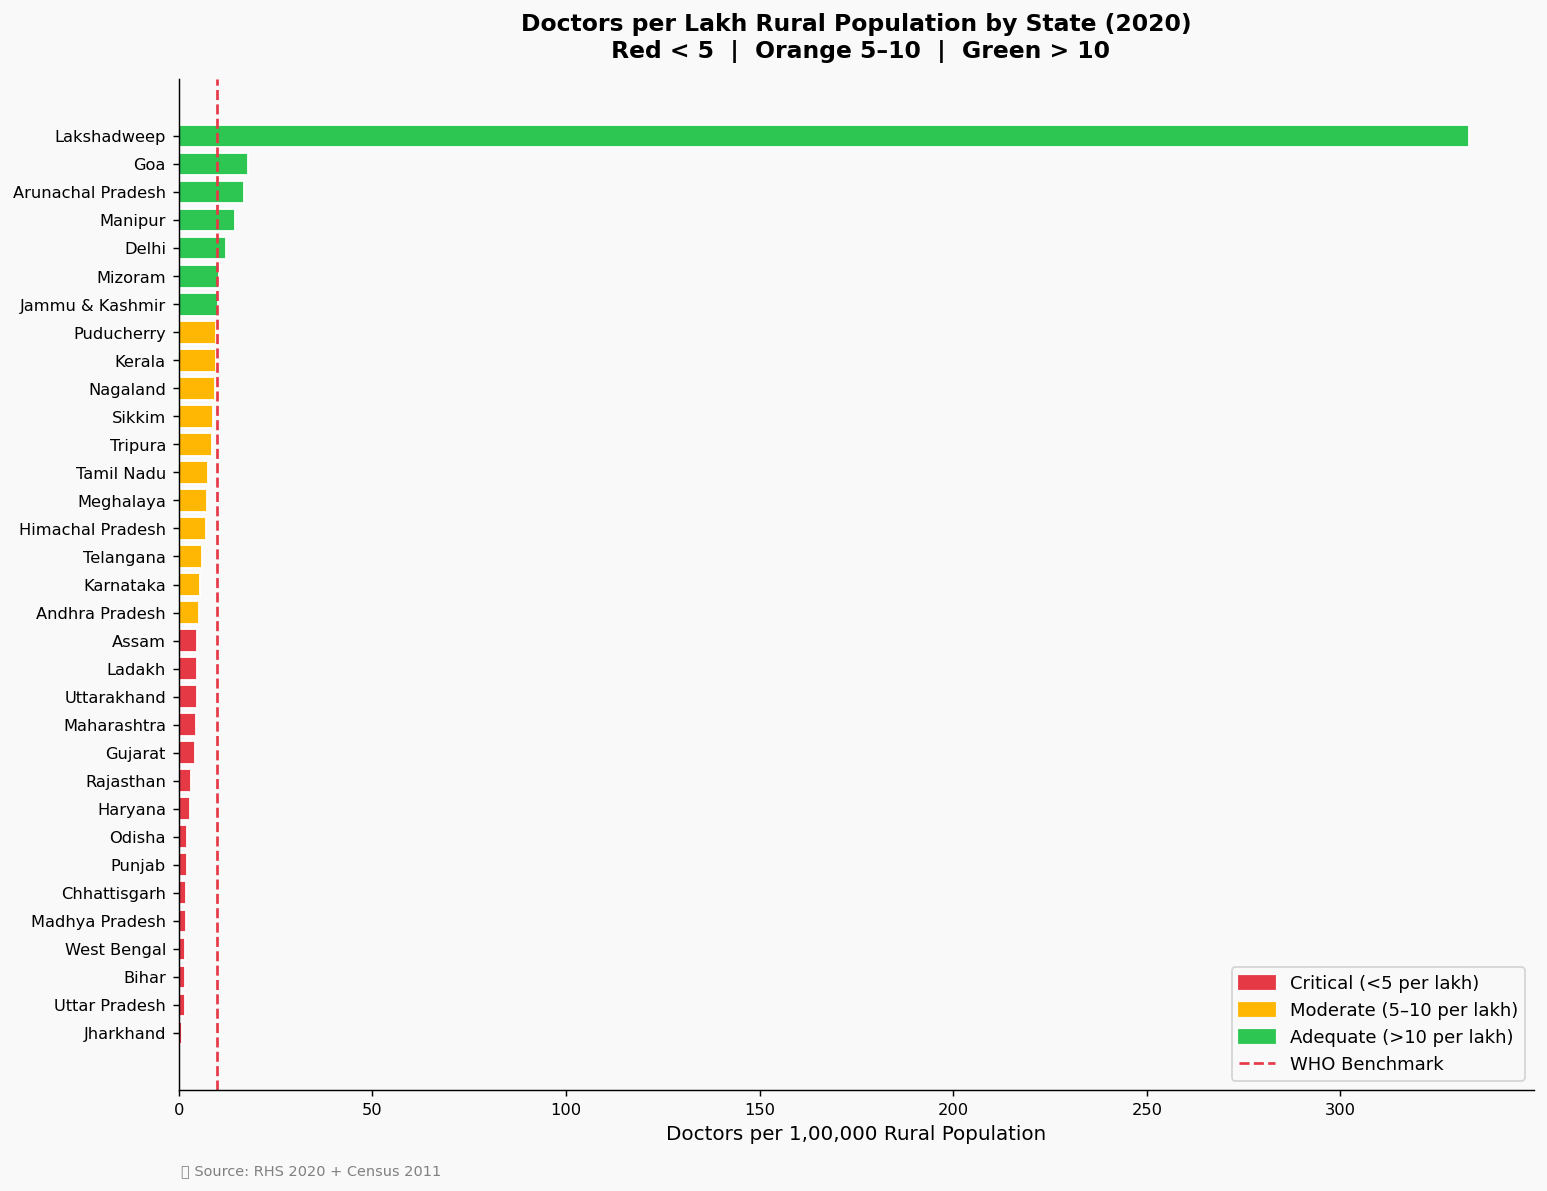


⚠️  15 states/UTs have fewer than 5 doctors per lakh rural population:
      State/UT  Doctors_per_lakh_rural
     Jharkhand                    0.78
 Uttar Pradesh                    1.58
         Bihar                    1.63
   West Bengal                    1.75
Madhya Pradesh                    1.78
  Chhattisgarh                    1.80
        Punjab                    2.19
        Odisha                    2.23
       Haryana                    2.83
     Rajasthan                    3.18
       Gujarat                    4.10
   Maharashtra                    4.41
   Uttarakhand                    4.68
        Ladakh                    4.76
         Assam                    4.83


In [10]:
plot_df = merged[['State/UT','Doctors_per_lakh_rural']].dropna().sort_values('Doctors_per_lakh_rural')

colors = ['#E63946' if x < 5 else '#FFB703' if x < 10 else '#2DC653'
          for x in plot_df['Doctors_per_lakh_rural']]

fig, ax = plt.subplots(figsize=(12, 9))
bars = ax.barh(plot_df['State/UT'], plot_df['Doctors_per_lakh_rural'], color=colors, edgecolor='white')
ax.axvline(10, color='#E63946', linestyle='--', linewidth=1.5, label='WHO Benchmark (~10/lakh)')
ax.set_xlabel('Doctors per 1,00,000 Rural Population')
ax.set_title('Doctors per Lakh Rural Population by State (2020)\n Red < 5  |  Orange 5–10  |  Green > 10', pad=12)

red_p   = mpatches.Patch(color='#E63946', label='Critical (<5 per lakh)')
org_p   = mpatches.Patch(color='#FFB703', label='Moderate (5–10 per lakh)')
grn_p   = mpatches.Patch(color='#2DC653', label='Adequate (>10 per lakh)')
who_l   = plt.Line2D([0],[0], color='#E63946', linestyle='--', label='WHO Benchmark')
ax.legend(handles=[red_p, org_p, grn_p, who_l], loc='lower right')
fig.text(0.12, -0.01, '📌 Source: RHS 2020 + Census 2011', fontsize=8, color='grey')
plt.tight_layout()
plt.show()

critical = plot_df[plot_df['Doctors_per_lakh_rural'] < 5]
print(f'\n⚠️  {len(critical)} states/UTs have fewer than 5 doctors per lakh rural population:')
print(critical[['State/UT','Doctors_per_lakh_rural']].to_string(index=False))

### 📊 Visualization 3 — Specialists Shortfall Across States (2020)

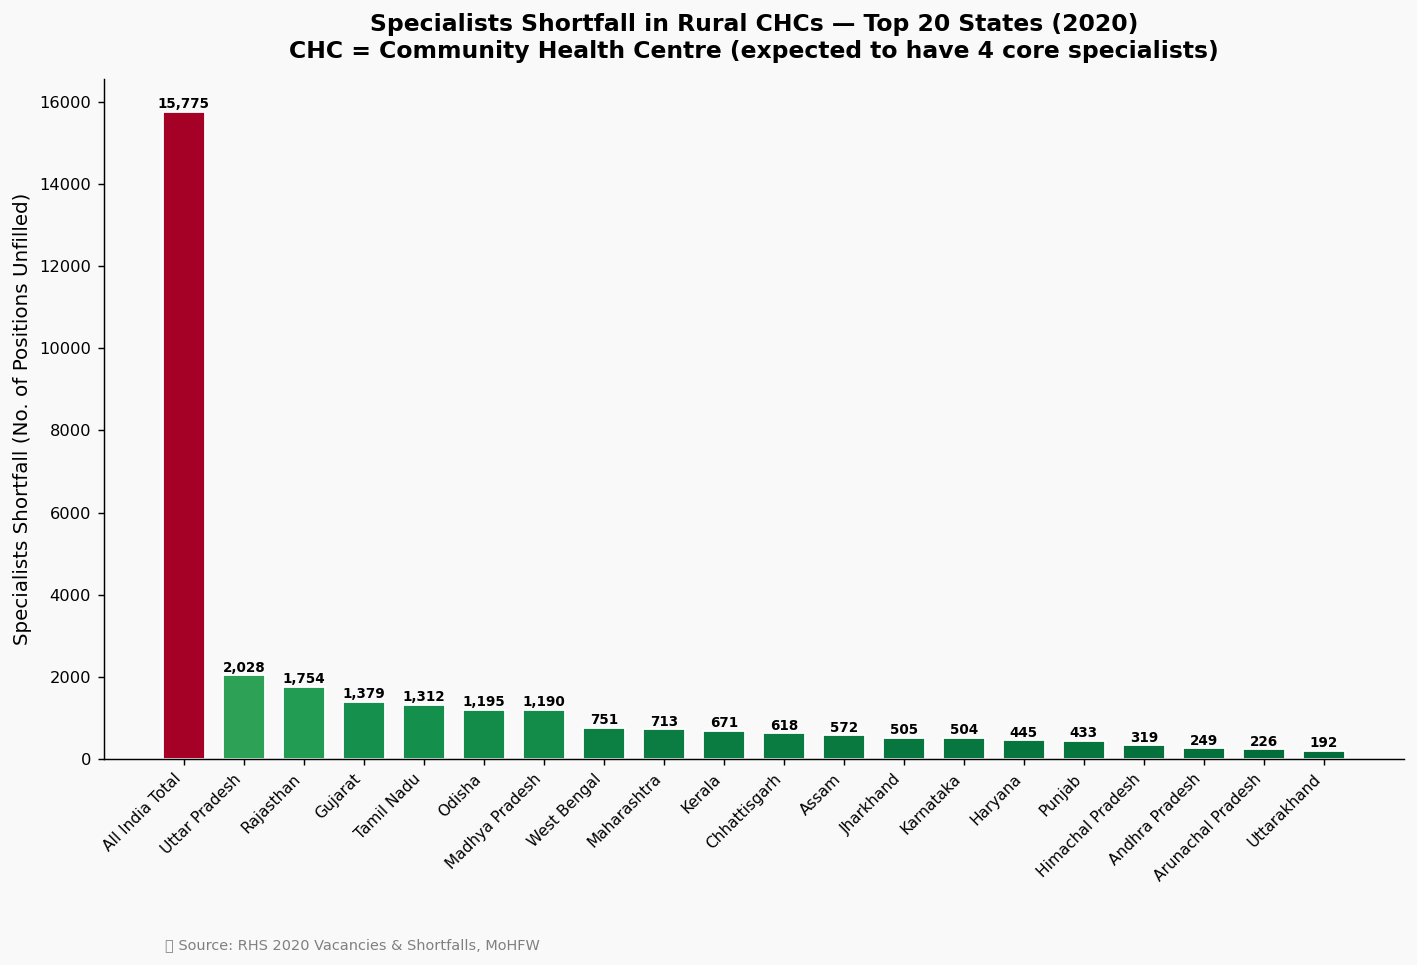


📊 Total Specialist Shortfall across top 20 states: 30,831


In [11]:
spec_df = vac[['State/UT','Specialists_Shortfall']].dropna()
spec_df['Specialists_Shortfall'] = pd.to_numeric(spec_df['Specialists_Shortfall'], errors='coerce')
spec_df = spec_df.dropna().sort_values('Specialists_Shortfall', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(11, 7))
cmap_vals = spec_df['Specialists_Shortfall'] / spec_df['Specialists_Shortfall'].max()
colors_spec = [plt.cm.RdYlGn_r(v) for v in cmap_vals]
bars = ax.bar(range(len(spec_df)), spec_df['Specialists_Shortfall'], color=colors_spec, edgecolor='white', width=0.7)
ax.set_xticks(range(len(spec_df)))
ax.set_xticklabels(spec_df['State/UT'], rotation=45, ha='right', fontsize=8.5)
ax.set_ylabel('Specialists Shortfall (No. of Positions Unfilled)')
ax.set_title('Specialists Shortfall in Rural CHCs — Top 20 States (2020)\n'
             'CHC = Community Health Centre (expected to have 4 core specialists)', pad=12)

for i, (bar, val) in enumerate(zip(bars, spec_df['Specialists_Shortfall'])):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'{int(val):,}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

fig.text(0.12, -0.05, '📌 Source: RHS 2020 Vacancies & Shortfalls, MoHFW', fontsize=8, color='grey')
plt.tight_layout()
plt.show()

total_shortfall = spec_df['Specialists_Shortfall'].sum()
print(f'\n📊 Total Specialist Shortfall across top 20 states: {int(total_shortfall):,}')

### 📊 Visualization 4 — Vacancy Heatmap Across All Staff Categories

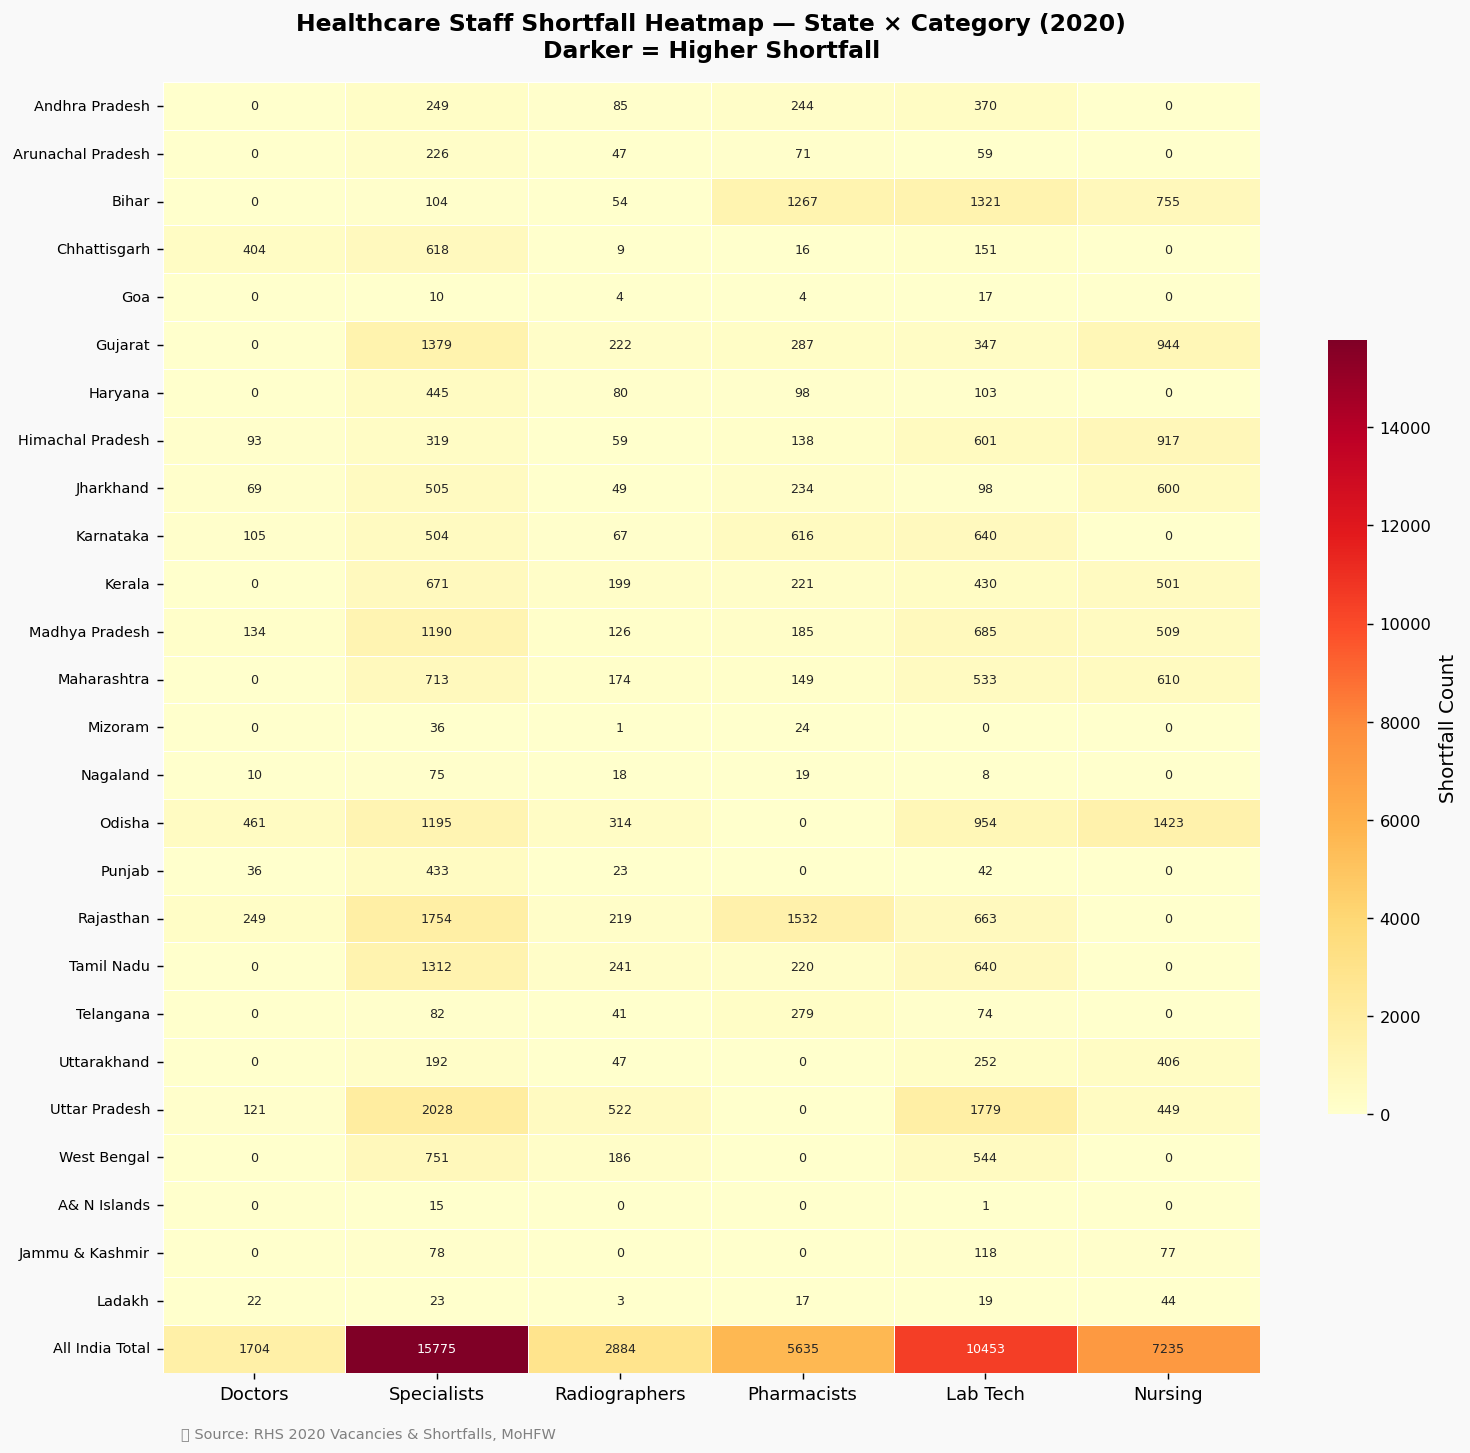

In [12]:
shortfall_cols = ['Doctors_Shortfall','Specialists_Shortfall',
                  'Radiographers_Shortfall','Pharmacists_Shortfall',
                  'LabTechnicians_Shortfall','Nursing_Shortfall']

heat_df = vac[['State/UT'] + shortfall_cols].copy()
for col in shortfall_cols:
    heat_df[col] = pd.to_numeric(heat_df[col], errors='coerce')
heat_df = heat_df.dropna(thresh=4)
heat_df.set_index('State/UT', inplace=True)
heat_df.columns = ['Doctors','Specialists','Radiographers','Pharmacists','Lab Tech','Nursing']

# Normalise row-wise so heatmap shows relative severity per state
heat_norm = heat_df.div(heat_df.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 11))
sns.heatmap(heat_df.fillna(0), ax=ax, cmap='YlOrRd',
            linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'Shortfall Count', 'shrink': 0.6},
            fmt='.0f', annot=True, annot_kws={'size': 7})
ax.set_title('Healthcare Staff Shortfall Heatmap — State × Category (2020)\n'
             'Darker = Higher Shortfall', pad=14, fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=8)
fig.text(0.12, -0.01, '📌 Source: RHS 2020 Vacancies & Shortfalls, MoHFW', fontsize=8, color='grey')
plt.tight_layout()
plt.show()

### 📊 Visualization 5 — Rural Population (%) vs Doctors per Lakh (Scatter)

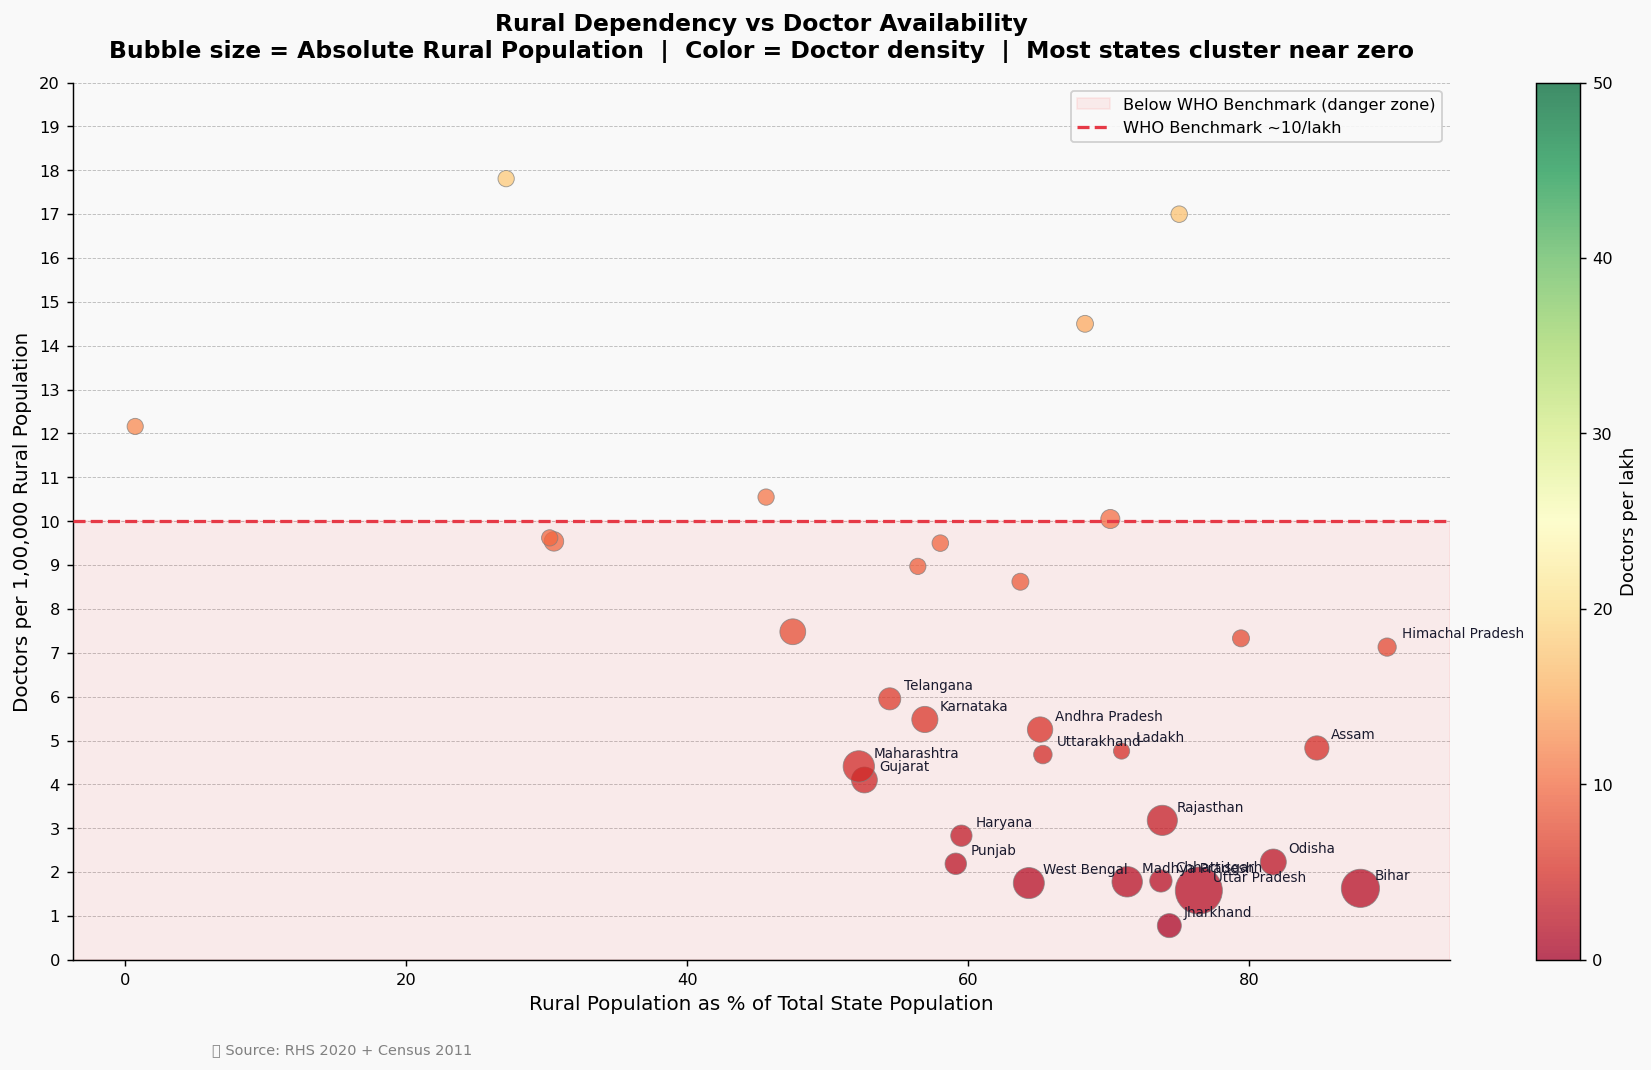

In [13]:
scatter_df = merged[['State/UT', 'Rural_Population_%', 'Doctors_per_lakh_rural', 'Rural_Population']].dropna()

# ── Exclude Lakshadweep ───────────────────────────────────────────────────────
scatter_df = scatter_df[scatter_df['State/UT'] != 'Lakshadweep']

fig, ax = plt.subplots(figsize=(14, 8))

size_vals = (scatter_df['Rural_Population'] / scatter_df['Rural_Population'].max() * 600 + 80)

sc = ax.scatter(scatter_df['Rural_Population_%'],
                scatter_df['Doctors_per_lakh_rural'],
                s=size_vals, alpha=0.75,
                c=scatter_df['Doctors_per_lakh_rural'],
                cmap='RdYlGn', edgecolors='grey', linewidth=0.5, zorder=3,
                vmin=0, vmax=50)

# ── Shade the danger zone below WHO benchmark ─────────────────────────────────
ax.axhspan(0, 10, alpha=0.06, color='red', label='Below WHO Benchmark (danger zone)')
ax.axhline(10, color='#E63946', linestyle='--', linewidth=1.8,
           label='WHO Benchmark ~10/lakh', zorder=4)

# ── Annotate notable states ───────────────────────────────────────────────────
always_label = [
    'Uttar Pradesh', 'Bihar', 'Madhya Pradesh', 'Jharkhand',
    'Himachal Pradesh', 'Assam', 'Odisha',
    'Rajasthan', 'West Bengal', 'Chhattisgarh'
]

for _, row in scatter_df.iterrows():
    label_this = (
        row['State/UT'] in always_label or
        row['Doctors_per_lakh_rural'] < 6 or
        row['Rural_Population_%'] > 85
    )
    if label_this:
        ax.annotate(
            row['State/UT'],
            (row['Rural_Population_%'], row['Doctors_per_lakh_rural']),
            fontsize=7.5,
            xytext=(8, 5),
            textcoords='offset points',
            color='#1a1a2e',
        )

# ── Labels & formatting ───────────────────────────────────────────────────────
ax.set_xlabel('Rural Population as % of Total State Population', fontsize=11)
ax.set_ylabel('Doctors per 1,00,000 Rural Population', fontsize=11)

ax.set_ylim(0, 20)                              # ← expanded range 0–50
ax.set_yticks(range(0, 21, 1))                  # ← ticks at 0, 5, 10, 15 ... 50
ax.set_yticklabels([str(i) for i in range(0, 21, 1)], fontsize=9)

# ── Optional: light horizontal gridlines at every tick for readability ────────
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.5, color='grey')
ax.set_axisbelow(True)

ax.set_title(
    'Rural Dependency vs Doctor Availability\n'
    'Bubble size = Absolute Rural Population  |  Color = Doctor density  |  Most states cluster near zero',
    fontsize=13, pad=14
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Doctors per lakh', fontsize=10)

ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
fig.text(0.12, -0.02, '📌 Source: RHS 2020 + Census 2011', fontsize=8, color='grey')

plt.tight_layout()
plt.savefig('chart5_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### 📊 Visualization 6 — Infrastructure Growth vs Workforce Gap (2005–2020)

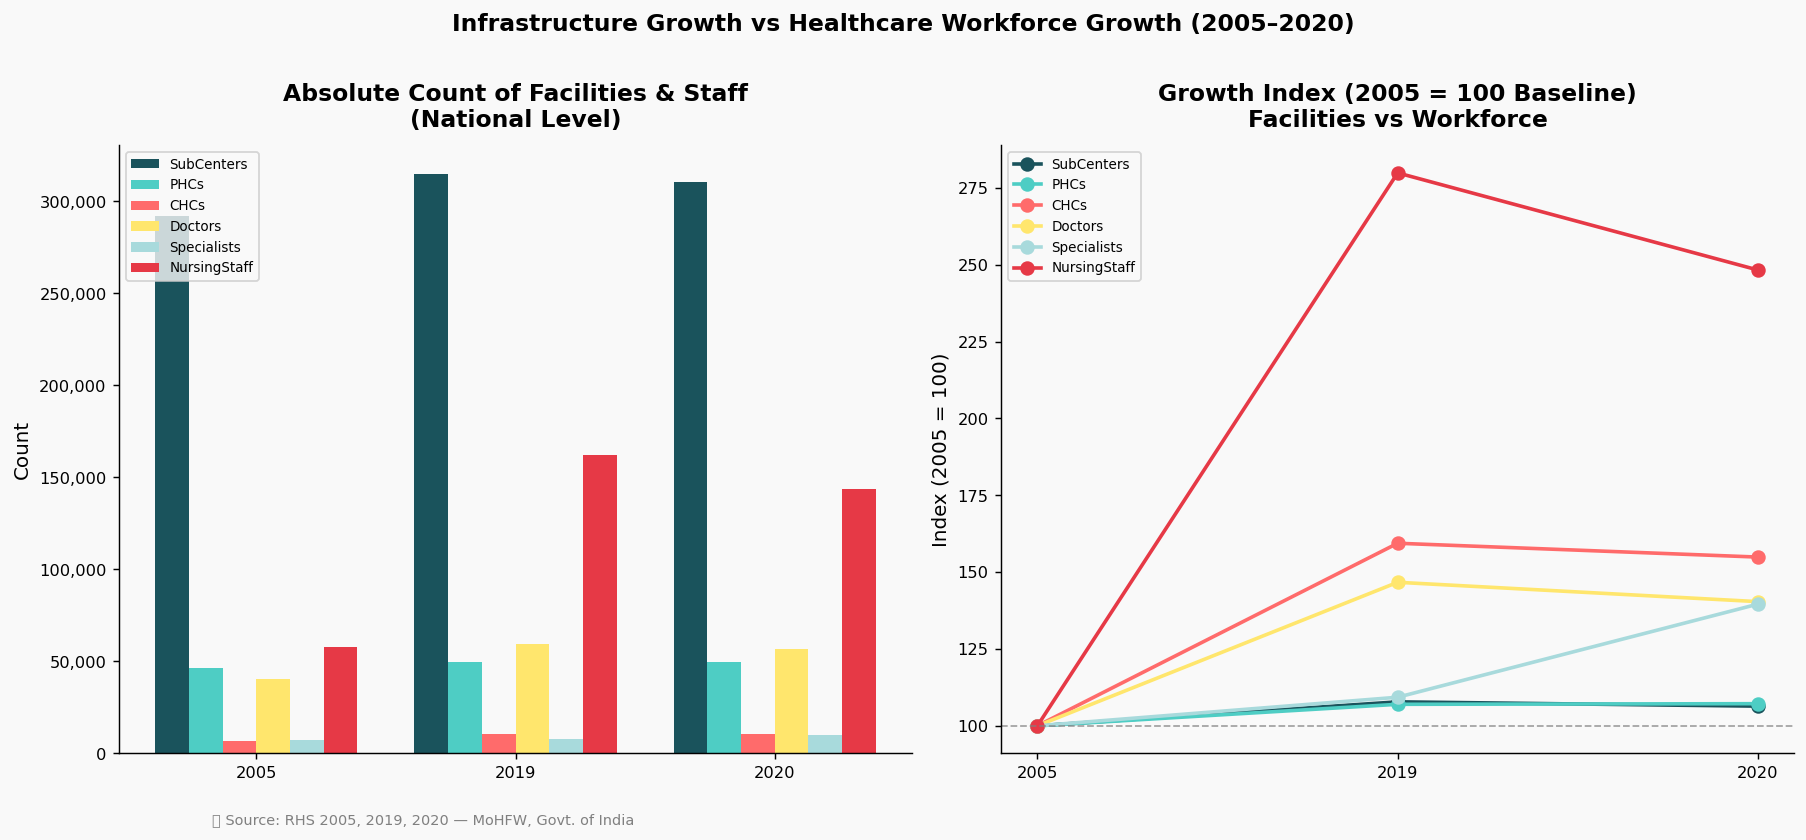


📋 Growth Index Summary (2005 → 2020):
               2005   2020
SubCenters    100.0  106.4
PHCs          100.0  107.2
CHCs          100.0  154.9
Doctors       100.0  140.4
Specialists   100.0  139.6
NursingStaff  100.0  248.3


In [14]:
# National aggregate — sum across all states for each year
metrics = ['SubCenters', 'PHCs', 'CHCs', 'Doctors', 'Specialists', 'NursingStaff']

agg05 = rhs05[metrics].sum()
agg19 = rhs19[metrics].sum()
agg20 = rhs20[metrics].sum()

agg = pd.DataFrame({'2005': agg05, '2019': agg19, '2020': agg20})
# Index as % of 2005 baseline
agg_idx = (agg.div(agg['2005'], axis=0) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: absolute values
ax = axes[0]
x = np.arange(3)
width = 0.13
colors_bar = ['#1A535C','#4ECDC4','#FF6B6B','#FFE66D','#A8DADC','#E63946']
for i, (metric, color) in enumerate(zip(metrics, colors_bar)):
    ax.bar(x + i*width, agg.loc[metric], width, label=metric, color=color)
ax.set_xticks(x + width*2.5)
ax.set_xticklabels(['2005','2019','2020'])
ax.set_title('Absolute Count of Facilities & Staff\n(National Level)', pad=10)
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.legend(fontsize=7.5, loc='upper left')

# Right: indexed growth
ax2 = axes[1]
for i, (metric, color) in enumerate(zip(metrics, colors_bar)):
    ax2.plot(['2005','2019','2020'], agg_idx.loc[metric], marker='o',
             label=metric, color=color, linewidth=2, markersize=7)
ax2.axhline(100, color='grey', linestyle='--', linewidth=1, alpha=0.7)
ax2.set_title('Growth Index (2005 = 100 Baseline)\nFacilities vs Workforce', pad=10)
ax2.set_ylabel('Index (2005 = 100)')
ax2.legend(fontsize=7.5, loc='upper left')

fig.suptitle('Infrastructure Growth vs Healthcare Workforce Growth (2005–2020)',
             fontsize=13, fontweight='bold', y=1.01)
fig.text(0.12, -0.03, '📌 Source: RHS 2005, 2019, 2020 — MoHFW, Govt. of India', fontsize=8, color='grey')
plt.tight_layout()
plt.show()

print('\n📋 Growth Index Summary (2005 → 2020):')
print(agg_idx[['2005','2020']].to_string())

### 📊 Visualization 7 — Doctors vs Specialists Vacancy Side-by-Side

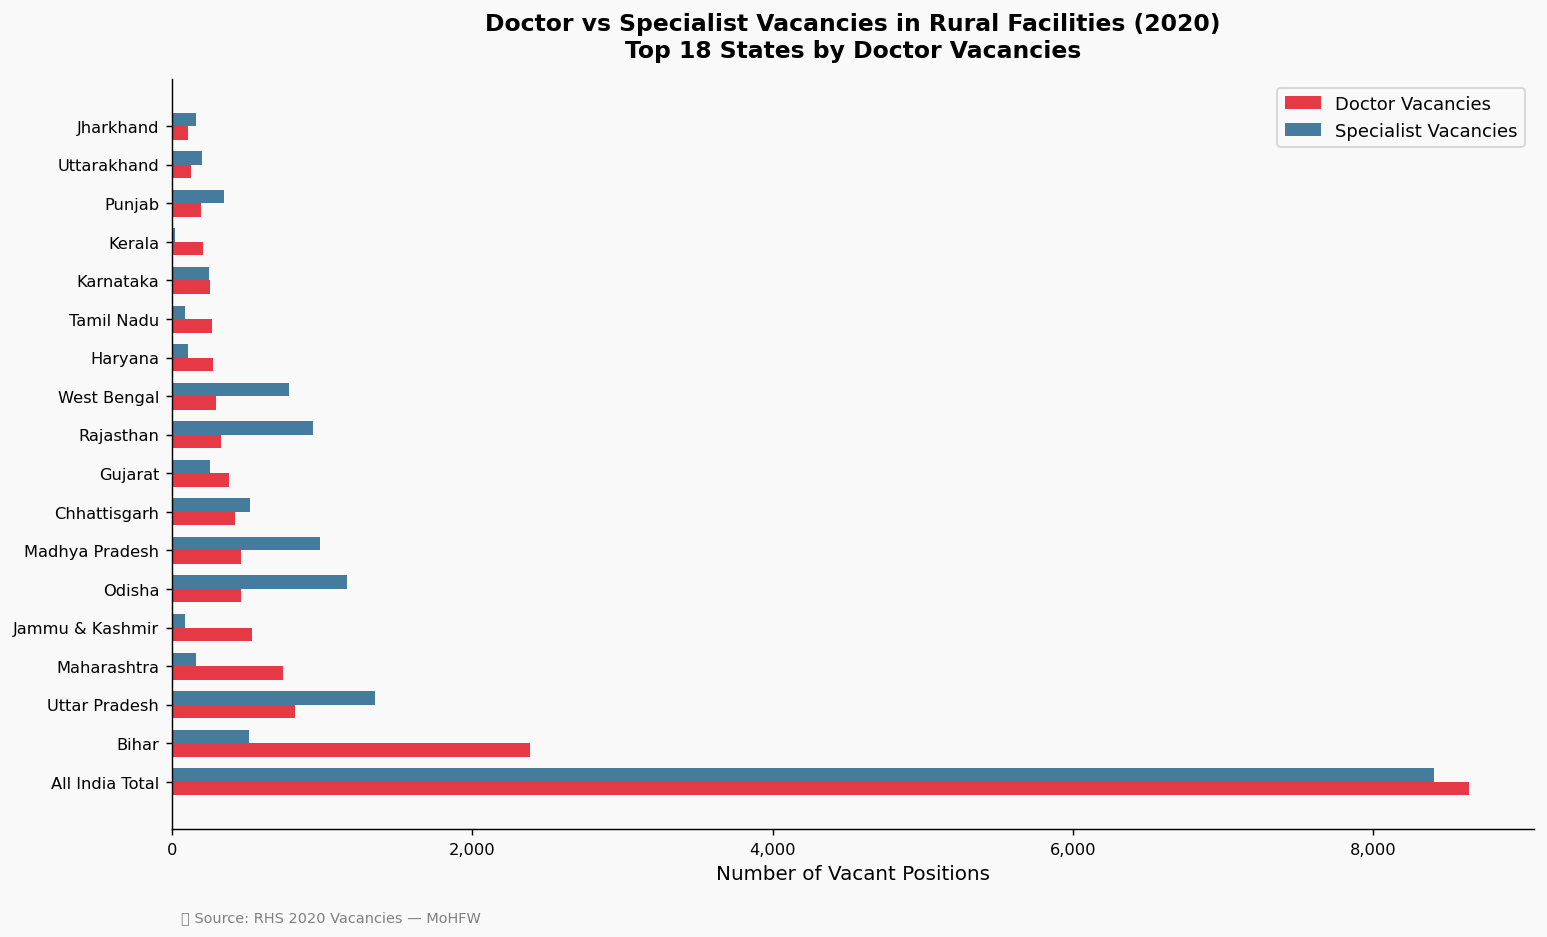

In [15]:
doc_vac = vac[['State/UT','Doctors_Vacent','Specialists_Vacent']].copy()
doc_vac['Doctors_Vacent']     = pd.to_numeric(doc_vac['Doctors_Vacent'], errors='coerce')
doc_vac['Specialists_Vacent'] = pd.to_numeric(doc_vac['Specialists_Vacent'], errors='coerce')
doc_vac = doc_vac.dropna().sort_values('Doctors_Vacent', ascending=False).head(18)

fig, ax = plt.subplots(figsize=(12, 7))
y = np.arange(len(doc_vac))
h = 0.35
ax.barh(y - h/2, doc_vac['Doctors_Vacent'],     h, color='#E63946', label='Doctor Vacancies')
ax.barh(y + h/2, doc_vac['Specialists_Vacent'], h, color='#457B9D', label='Specialist Vacancies')
ax.set_yticks(y)
ax.set_yticklabels(doc_vac['State/UT'], fontsize=9)
ax.set_xlabel('Number of Vacant Positions')
ax.set_title('Doctor vs Specialist Vacancies in Rural Facilities (2020)\n'
             'Top 18 States by Doctor Vacancies', pad=12)
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
fig.text(0.12, -0.02, '📌 Source: RHS 2020 Vacancies — MoHFW', fontsize=8, color='grey')
plt.tight_layout()
plt.show()

### 📊 Visualization 8 — State Vulnerability Index (Composite Score)

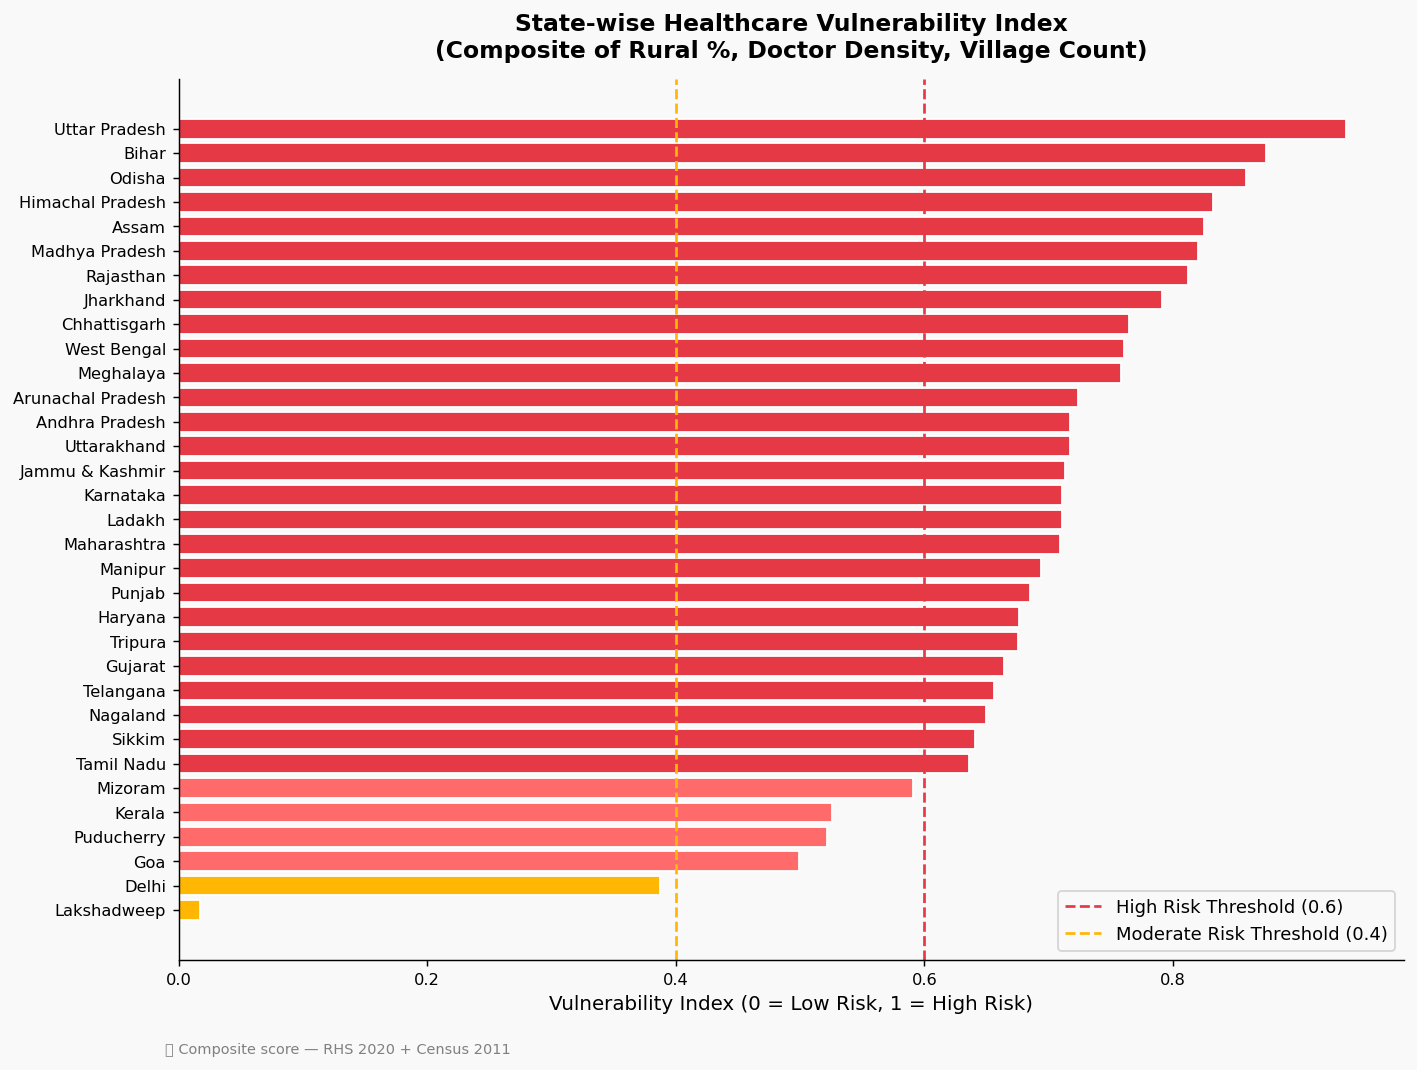


🔴 Most Vulnerable States (Index > 0.6):
         State/UT  Vulnerability_Index  Rural_Population_%  Doctors_per_lakh_rural
    Uttar Pradesh                0.939                76.4                    1.58
            Bihar                0.875                87.9                    1.63
           Odisha                0.859                81.7                    2.23
 Himachal Pradesh                0.832                89.8                    7.13
            Assam                0.825                84.8                    4.83
   Madhya Pradesh                0.820                71.3                    1.78
        Rajasthan                0.812                73.8                    3.18
        Jharkhand                0.791                74.3                    0.78
     Chhattisgarh                0.765                73.7                    1.80
      West Bengal                0.761                64.3                    1.75
        Meghalaya                0.758        

In [16]:
# Composite index: high rural %, low doctors/lakh, many villages, few doctors
comp = merged[['State/UT','Rural_Population_%','Doctors_per_lakh_rural',
               'Number_of_Villages','Doctors']].dropna()

# Normalise each component 0–1
def norm_01(s, invert=False):
    mn, mx = s.min(), s.max()
    n = (s - mn) / (mx - mn)
    return 1 - n if invert else n

comp = comp.copy()
comp['score_rural_pct']    = norm_01(comp['Rural_Population_%'])          # high = bad
comp['score_low_doctors']  = norm_01(comp['Doctors_per_lakh_rural'], invert=True)  # low = bad
comp['score_villages']     = norm_01(comp['Number_of_Villages'])          # more = harder to reach
comp['Vulnerability_Index'] = (comp['score_rural_pct'] * 0.4
                                + comp['score_low_doctors'] * 0.4
                                + comp['score_villages'] * 0.2).round(3)
comp = comp.sort_values('Vulnerability_Index', ascending=False)

fig, ax = plt.subplots(figsize=(11, 8))
bar_colors = ['#E63946' if v > 0.6 else '#FF6B6B' if v > 0.4 else '#FFB703'
              for v in comp['Vulnerability_Index']]
ax.barh(comp['State/UT'], comp['Vulnerability_Index'], color=bar_colors, edgecolor='white')
ax.axvline(0.6, color='#E63946', linestyle='--', linewidth=1.5, label='High Risk Threshold (0.6)')
ax.axvline(0.4, color='#FFB703', linestyle='--', linewidth=1.5, label='Moderate Risk Threshold (0.4)')
ax.set_xlabel('Vulnerability Index (0 = Low Risk, 1 = High Risk)')
ax.set_title('State-wise Healthcare Vulnerability Index\n'
             '(Composite of Rural %, Doctor Density, Village Count)', pad=12)
ax.legend(loc='lower right')
ax.invert_yaxis()
fig.text(0.12, -0.02, '📌 Composite score — RHS 2020 + Census 2011', fontsize=8, color='grey')
plt.tight_layout()
plt.show()

print('\n🔴 Most Vulnerable States (Index > 0.6):')
print(comp[comp['Vulnerability_Index'] > 0.6][['State/UT','Vulnerability_Index',
      'Rural_Population_%','Doctors_per_lakh_rural']].to_string(index=False))

### 📊 Visualization 9 — PHC & CHC Expansion vs Actual Doctor Posting

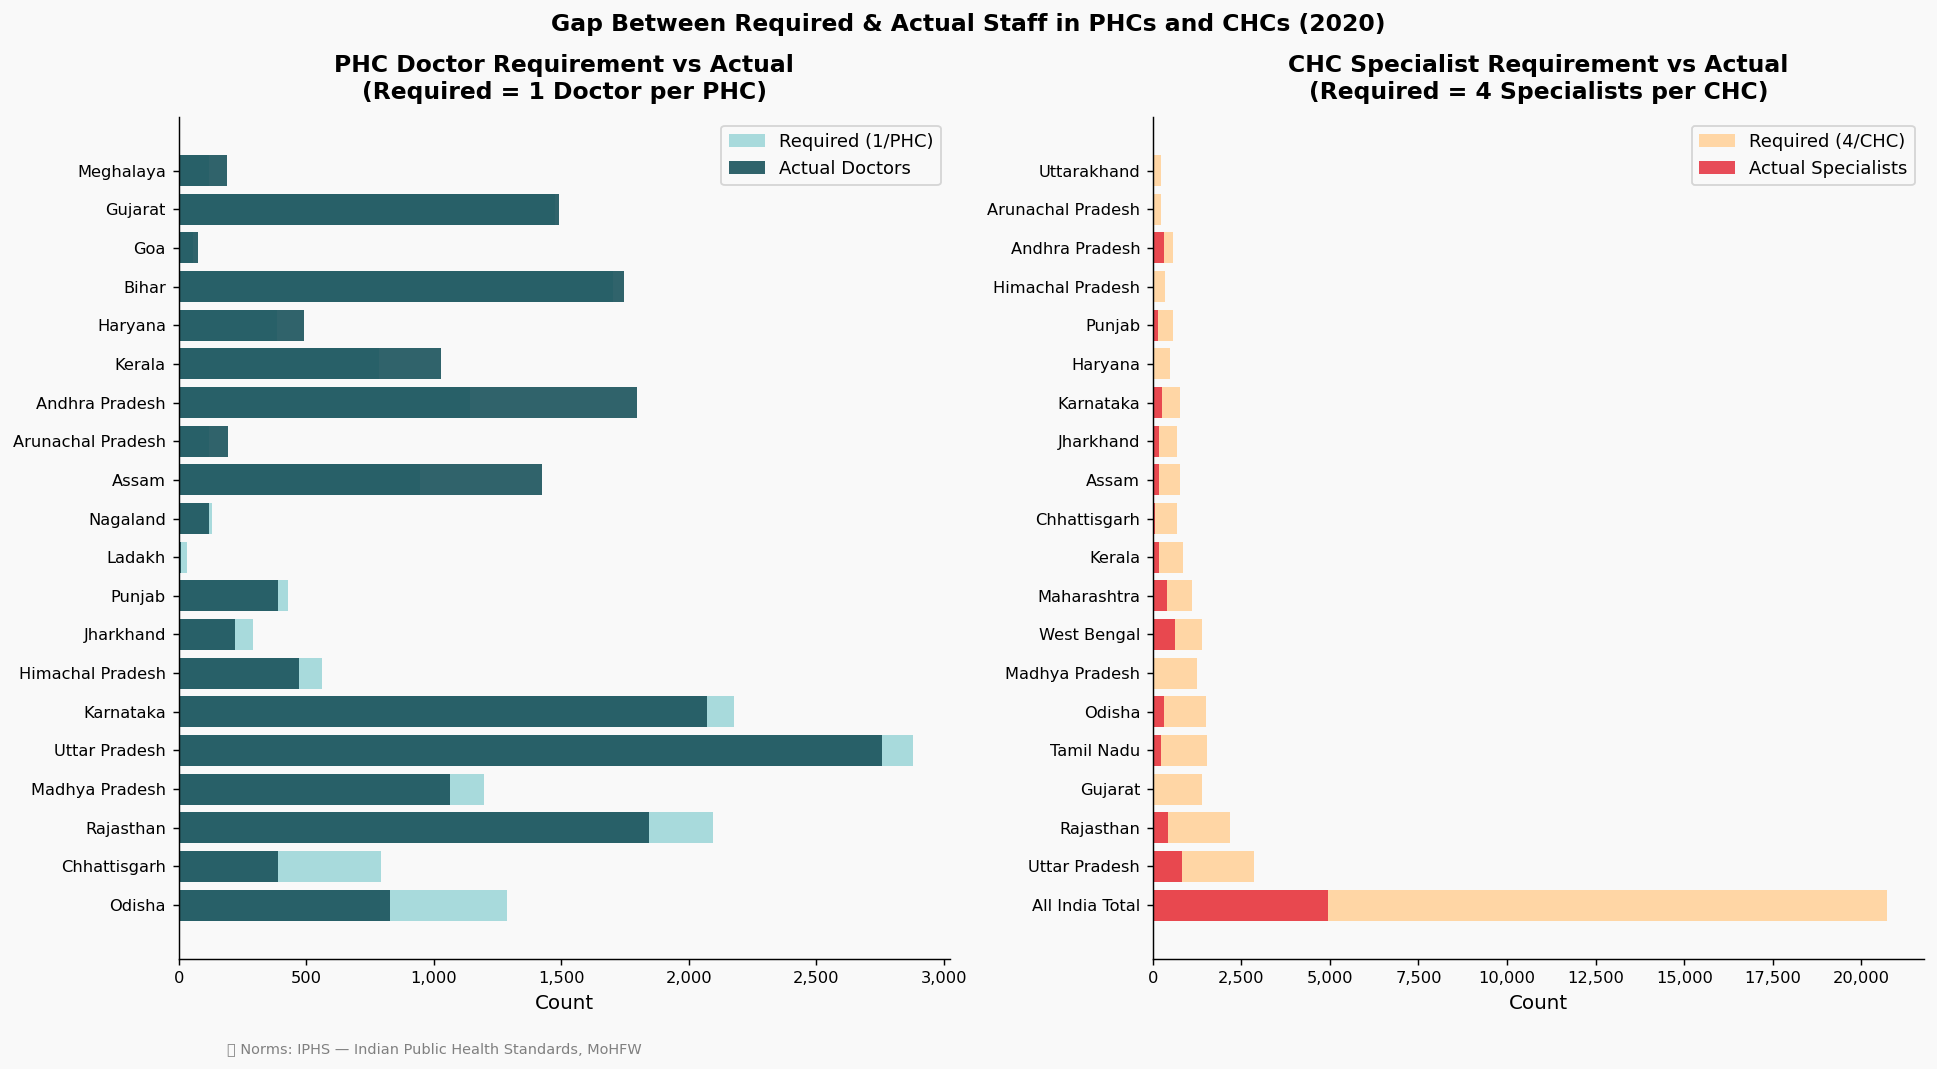


📊 National Doctor Gap (vs PHC requirement):     1,704 positions
📊 National Specialist Gap (vs CHC requirement): 31,550 positions


In [17]:
# PHC norm: 1 doctor per PHC | CHC norm: 4 specialists per CHC
gap = rhs20[['State/UT','PHCs','CHCs','Doctors','Specialists']].dropna()
gap = gap.copy()
gap['Required_Doctors_PHC']     = gap['PHCs']              # 1 doctor per PHC
gap['Required_Specialists_CHC'] = gap['CHCs'] * 4          # 4 specialists per CHC (Indian Norm)
gap['Doctor_Gap']               = gap['Required_Doctors_PHC'] - gap['Doctors']
gap['Specialist_Gap']           = gap['Required_Specialists_CHC'] - gap['Specialists']
gap['Doctor_Gap']               = gap['Doctor_Gap'].clip(lower=0)
gap['Specialist_Gap']           = gap['Specialist_Gap'].clip(lower=0)

gap_sorted = gap.sort_values('Doctor_Gap', ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(15, 8))

ax1 = axes[0]
ax1.barh(gap_sorted['State/UT'], gap_sorted['Required_Doctors_PHC'],
         color='#A8DADC', label='Required (1/PHC)')
ax1.barh(gap_sorted['State/UT'], gap_sorted['Doctors'],
         color='#1A535C', alpha=0.9, label='Actual Doctors')
ax1.set_title('PHC Doctor Requirement vs Actual\n(Required = 1 Doctor per PHC)', pad=10)
ax1.set_xlabel('Count')
ax1.legend()
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

gap_sorted2 = gap.sort_values('Specialist_Gap', ascending=False).head(20)
ax2 = axes[1]
ax2.barh(gap_sorted2['State/UT'], gap_sorted2['Required_Specialists_CHC'],
         color='#FFD6A5', label='Required (4/CHC)')
ax2.barh(gap_sorted2['State/UT'], gap_sorted2['Specialists'],
         color='#E63946', alpha=0.9, label='Actual Specialists')
ax2.set_title('CHC Specialist Requirement vs Actual\n(Required = 4 Specialists per CHC)', pad=10)
ax2.set_xlabel('Count')
ax2.legend()
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

fig.suptitle('Gap Between Required & Actual Staff in PHCs and CHCs (2020)',
             fontsize=13, fontweight='bold')
fig.text(0.12, -0.02, '📌 Norms: IPHS — Indian Public Health Standards, MoHFW', fontsize=8, color='grey')
plt.tight_layout()
plt.show()

total_doc_gap  = gap['Doctor_Gap'].sum()
total_spec_gap = gap['Specialist_Gap'].sum()
print(f'\n📊 National Doctor Gap (vs PHC requirement):     {int(total_doc_gap):,} positions')
print(f'📊 National Specialist Gap (vs CHC requirement): {int(total_spec_gap):,} positions')

---
## Section 5 — Key Insights & Problem Framing

### 🔍 Summary of Findings

| # | Insight | Evidence |
|---|---|---|
| 1 | **Infrastructure outpaced workforce**: The number of Sub-Centres, PHCs, and CHCs grew significantly between 2005–2020, but the number of doctors did not grow proportionally | Growth Index chart (Vis 6) |
| 2 | **Specialist crisis at CHCs**: Most states have a massive gap between the 4-specialist norm per CHC and actual deployed specialists | Vis 3, Vis 9 |
| 3 | **More rural = fewer doctors per capita**: States with higher rural population share consistently have lower doctor density — a direct equity gap | Vis 5 (correlation) |
| 4 | **Vacancies are normalised**: In many states, vacant positions persist year after year — it's a structural, not temporary, problem | Vis 4 (heatmap), Vis 7 |
| 5 | **High-risk states cluster in heartland India**: States like Uttar Pradesh, Bihar, Jharkhand, and Rajasthan dominate the vulnerability index | Vis 8 |

---

### 🏗️ System-Level Causes
- **Incentive gap**: Urban hospitals offer higher salaries, better facilities, and career growth
- **Quality of life**: Rural postings often lack housing, schools, and infrastructure for doctors' families
- **Regulatory mismatch**: Sanctioned posts exist on paper but remain unfilled for years due to state-level bureaucracy
- **Specialist pipeline**: Medical colleges concentrate in cities; rural exposure during training is minimal

---

### 👥 Who Is Affected
- **~65–85% of the population** in many states lives in rural areas and depends on PHCs and CHCs
- **Women and children** are disproportionately affected — maternal mortality and child health outcomes are worse in doctor-scarce districts
- **Elderly and chronic patients** who cannot travel to urban hospitals

---

### 📐 Measurable Data Patterns Identified
1. `Doctors_per_lakh_rural` — primary metric for equity monitoring
2. `Specialist_Gap = (CHCs × 4) - Actual Specialists` — gap metric for specialist crisis
3. `Vulnerability_Index` — composite state ranking for policy targeting
4. Year-on-year trend of infrastructure vs workforce growth

---

### 🚀 Potential Data-Driven Interventions (For Future Phases)
- Predictive modelling of vacancy likelihood by state characteristics
- Clustering states by shortage profile for targeted incentive policy
- Geo-spatial mapping of village distance to nearest functional PHC
- Forecasting doctor demand by 2030 based on population trends

---
## Section 6 — Data Source & Methodology

### Primary Data Source
**Publication:** Rural Health Statistics (RHS) — renamed *Health Dynamics of India (Infrastructure and Human Resources)* from 2022-23 onwards  
**Publisher:** Ministry of Health and Family Welfare (MoHFW), Government of India  
**Published since:** 1992, annually  
**Reference date:** Data collected as on 31st March each year  

### Data Collection Methodology
- State and Union Territory governments submit facility-level data to MoHFW annually
- Data covers Sub-Centres (SCs), Primary Health Centres (PHCs), Community Health Centres (CHCs), Sub-Divisional/District Hospitals, and Medical Colleges
- Validated against the Health Management Information System (HMIS) portal and Indian Public Health Standards (IPHS) benchmarks
- Cross-referenced with national Census data and broader national surveys

### Years Used in This Analysis
| Year | Source |
|------|--------|
| 2005 | RHS 2005, MoHFW |
| 2019 | RHS 2019, MoHFW |
| 2020 | RHS 2020, MoHFW |
| 2021 | RHS 2020-21, MoHFW |
| 2022 | RHS 2021-22, MoHFW |
| 2023 | Health Dynamics of India 2022-23, MoHFW (Press Release, PIB, Sept 2024) |

### Access
All reports available at: https://mohfw.gov.in → Documents → Rural Health Statistics


---
## Section 7 — Updated Data: 2021 & 2022

**Sources:** RHS 2020-21, RHS 2021-22 (MoHFW, Government of India)

**Note:** RHS 2022-23 (Health Dynamics of India) was released via PIB Press Release (Sept 2024) but reports specialist figures inclusive of Sub-Divisional and District Hospitals — not comparable to the CHC-only baseline used in this analysis. Latest comparable data is therefore 2021-22.

Key finding from updated data: Specialist shortfall remains critical. Despite CHC infrastructure growing from 5,895 (2020) to 6,172 (2022), the workforce gap has barely improved. The system keeps building facilities without deploying the doctors to run them.


All-India Healthcare Infrastructure Timeline
 Year  CHCs  PHCs  Specialists_InPos  Doctors_PHC
 2005  4044 23236               3550        20308
 2019  5335 25743               3960        27421
 2020  5895 28702               4405        30045
 2021  5481 25140               4405        31716
 2022  5480 24935               4485        30640

Specialist Shortfall Trend at CHCs (Rural)
 Year  Required  InPos  Shortfall  Shortfall_pct
 2020     23580   4405      19175           81.3
 2021     21924   4405      17519           79.9
 2022     21920   4485      17435           79.5


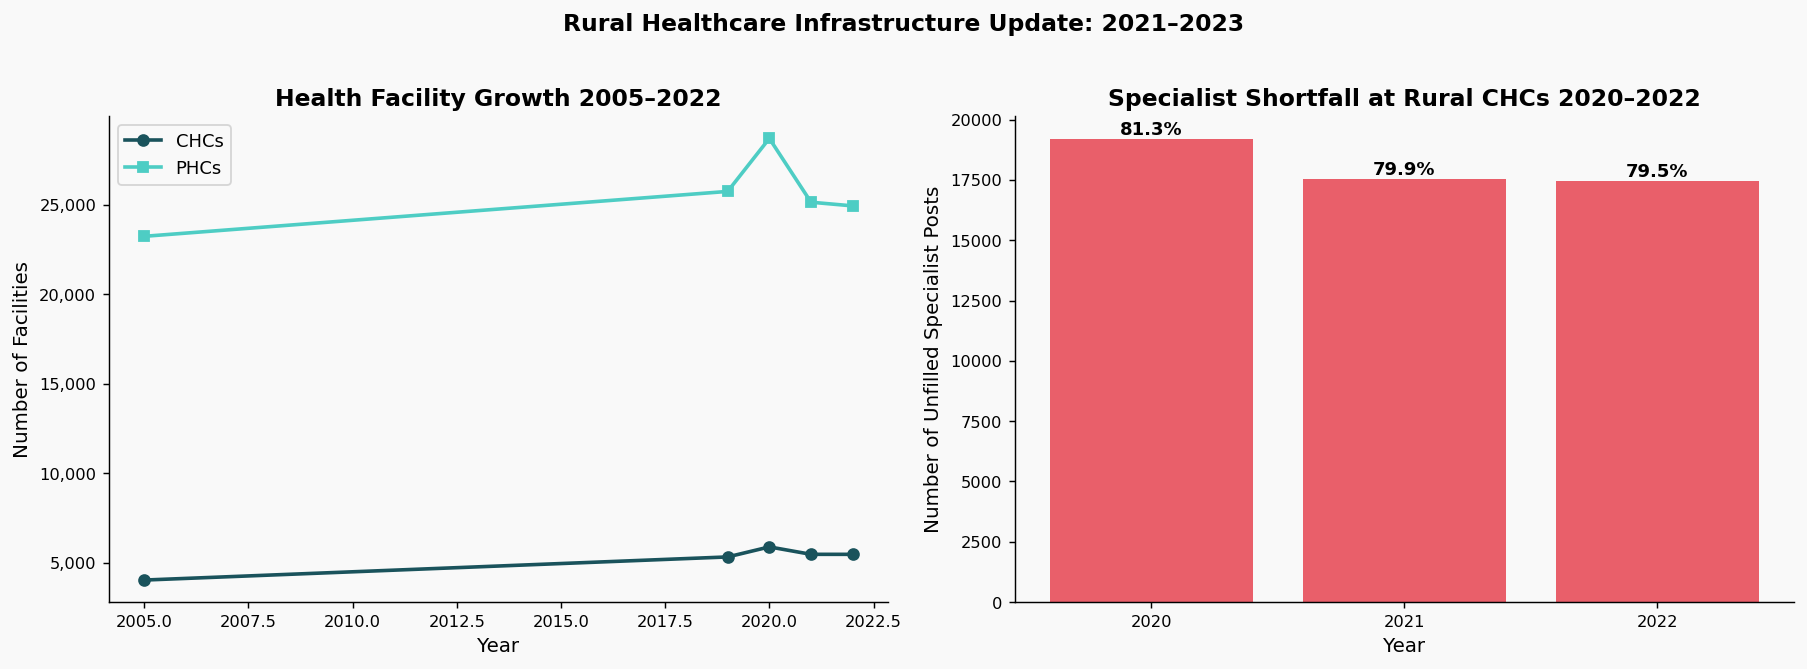


Source: RHS 2020-21, RHS 2021-22, Health Dynamics of India 2022-23, MoHFW


In [18]:
# ── Section 7: Updated Infrastructure Data 2021, 2022 & 2023 ────────────────
# Source: RHS 2020-21, RHS 2021-22 (MoHFW); Health Dynamics of India 2022-23 (PIB Press Release, Sept 2024)
# Data verified against official PDFs (June 2026)

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

DATA_PATH = os.path.join('datasets', 'RHS_Healthcare_Infrastructure_2020-2022.xlsx')

def load_all_india(sheet_name):
    df = pd.read_excel(DATA_PATH, sheet_name=sheet_name, header=None)
    df.columns = df.iloc[2]
    df = df.iloc[3:].reset_index(drop=True)
    df.columns = ['SNo', 'State', 'Sanctioned', 'InPosition', 'Vacant']
    row = df[df['State'].astype(str).str.contains('All India|Total', na=False, case=False)]
    if len(row) > 0:
        return pd.to_numeric(row.iloc[0]['InPosition'], errors='coerce')
    return None

# Load All-India in-position values from Excel
doc_2021 = load_all_india('Doctors_PHC_2021')   # Should be 31,716
doc_2022 = load_all_india('Doctors_PHC_2022')   # Should be 30,640
spec_2021 = load_all_india('Specialists_CHC_2021')  # Should be 4,405
spec_2022 = load_all_india('Specialists_CHC_2022')  # Should be 4,485

print(f'Loaded from Excel:')
print(f'  Doctors PHC 2021:    {doc_2021:,.0f}')
print(f'  Doctors PHC 2022:    {doc_2022:,.0f}')
print(f'  Specialists CHC 2021: {spec_2021:,.0f}')
print(f'  Specialists CHC 2022: {spec_2022:,.0f}')

# ── All-India summary timeline ────────────────────────────────────────────────
# 2023 data from PIB Press Release, Sept 2024 (Health Dynamics of India 2022-23)
timeline = pd.DataFrame({
    'Year':             [2005,  2019,  2020,  2021,  2022,  2023],
    'CHCs':             [4044,  5335,  5895,  5481,  5480,  6359],
    'PHCs':             [23236, 25743, 28702, 25140, 24935, 31882],
    'Specialists_InPos':[3550,  3960,  4405,  spec_2021, spec_2022, 26280],
    'Doctors_PHC':      [20308, 27421, 30045, doc_2021, doc_2022, 40583],
})

print('\nAll-India Healthcare Infrastructure Timeline (2005-2023)')
print(timeline.to_string(index=False))

# ── Specialist shortfall trend ────────────────────────────────────────────────
shortfall_data = pd.DataFrame({
    'Year':      [2020,  2021,   2022],
    'Required':  [23580, 21924,  21920],
    'InPos':     [4405,  spec_2021, spec_2022],
    'Shortfall': [19175, 17519,  17435],
})
shortfall_data['Shortfall_pct'] = (shortfall_data['Shortfall']/shortfall_data['Required']*100).round(1)

print('\nSpecialist Shortfall Trend at Rural CHCs')
print(shortfall_data.to_string(index=False))

# ── Charts ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(timeline['Year'], timeline['CHCs'], 'o-', color='#1A535C', linewidth=2, label='CHCs')
axes[0].plot(timeline['Year'], timeline['PHCs'], 's-', color='#4ECDC4', linewidth=2, label='PHCs')
axes[0].set_title('Health Facility Growth 2005–2023', fontweight='bold')
axes[0].set_ylabel('Number of Facilities')
axes[0].set_xlabel('Year')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].bar(shortfall_data['Year'].astype(str), shortfall_data['Shortfall'], color='#E63946', alpha=0.8)
axes[1].set_title('Specialist Shortfall at Rural CHCs 2020–2022', fontweight='bold')
axes[1].set_ylabel('Unfilled Specialist Posts')
axes[1].set_xlabel('Year')
for i, (_, row) in enumerate(shortfall_data.iterrows()):
    axes[1].text(i, row['Shortfall'] + 200, f"{row['Shortfall_pct']}%", ha='center', fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Rural Healthcare Infrastructure Update: 2021–2023\nSource: RHS 2020-21, RHS 2021-22, Health Dynamics of India 2022-23 — MoHFW', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('chart_updated_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
